In [1]:
# ============================================================
# Setup
# ============================================================
import sys, os
_d = os.path.abspath(os.getcwd())
for _ in range(5):
    if os.path.isfile(os.path.join(_d, 'config.py')):
        break
    _d = os.path.dirname(_d)
sys.path.insert(0, os.path.join(_d, 'src'))
sys.path.insert(0, _d)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator
from scipy import stats
from config import SUBJECTS, cv_result_csv, FIGURES_DIR

# Publication-quality defaults
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 13,
    'axes.linewidth': 1.3,
    'xtick.major.width': 1.3,
    'ytick.major.width': 1.3,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

def tidy_yticks(ax, n=3):
    """Reduce number of y-ticks for a cleaner publication look."""
    ax.yaxis.set_major_locator(MaxNLocator(nbins=n, prune=None))

STAGES   = ['4.6', '4.7', '4.8']
STAGE_X  = [0, 1, 2]   # integer x-positions; labels set separately
STAGE_LABELS = ['4.6', '4.7', '4.8']
print('Setup complete. Figures will be saved to:', FIGURES_DIR)

Setup complete. Figures will be saved to: /gpfs/radev/project/kuan/my483/RL_twostep/twostep-model-comparison/figures


In [2]:
# ============================================================
# Colour map & model registry
# ============================================================
COLOUR_MAP = {
    'MF':                     '#E41E27',
    'Hybrid':               '#43A047',
    'MB':                    '#1976D2',
    'RAC+P':               '#00ACC1',
    'Asymmetric Inference': '#7B1FA2',
    'LS':                    '#CE93D8'
}

# model CSV key  ->  (display label, colour key)
MODEL_META = {
    'hyb':           ('Hybrid',          'Hybrid'),
    'hyb_p':         ('Hybrid+P',        'Hybrid'),
    'hyb_pmulti':    ('Hybrid+Pmulti',   'Hybrid'),
    'hyb_inf':       ('Hybrid+Inf',      'Hybrid'),
    'mb':            ('MB',              'MB'),
    'mb_p':          ('MB+P',            'MB'),
    'mb_pmulti':     ('MB+Pmulti',       'MB'),
    'mf_p':          ('MF+P',            'MF'),
    'mf_pmulti':     ('MF+Pmulti',       'MF'),
    'ls_asym':       ('Asymmetric Inference',       'Asymmetric Inference'),      
    'ls_asym_p':     ('Inference+P',     'Asymmetric Inference'),
    'ls_asym_pmulti':('Inference+Pmulti','Asymmetric Inference'),
    'ls':           ('LS',              'LS'),
    'ls_p':         ('LS+P',            'LS'),
    'rac_p':         ('RAC+P',           'RAC+P'),
}

def clr(model_key):
    """Return hex colour for a model key."""
    ck = MODEL_META[model_key][1]
    return COLOUR_MAP.get(ck, '#888888')

def lbl(model_key):
    """Return display label for a model key."""
    return MODEL_META[model_key][0]

In [3]:
# ============================================================
# Load all CV CSV files
# ============================================================
ALL_MODELS = list(MODEL_META.keys())

dfs = {}
for model in ALL_MODELS:
    for stage in STAGES:
        path = cv_result_csv(model, stage)
        if os.path.exists(path):
            dfs[(model, stage)] = pd.read_csv(path)

# Quick overview
print(f'Loaded {len(dfs)} data files.')
for model in ALL_MODELS:
    loaded = [s for s in STAGES if (model, s) in dfs]
    missing = [s for s in STAGES if (model, s) not in dfs]
    tag = '  MISSING:' + str(missing) if missing else ''
    print(f'  {model:<20}  stages={loaded}{tag}')

Loaded 45 data files.
  hyb                   stages=['4.6', '4.7', '4.8']
  hyb_p                 stages=['4.6', '4.7', '4.8']
  hyb_pmulti            stages=['4.6', '4.7', '4.8']
  hyb_inf               stages=['4.6', '4.7', '4.8']
  mb                    stages=['4.6', '4.7', '4.8']
  mb_p                  stages=['4.6', '4.7', '4.8']
  mb_pmulti             stages=['4.6', '4.7', '4.8']
  mf_p                  stages=['4.6', '4.7', '4.8']
  mf_pmulti             stages=['4.6', '4.7', '4.8']
  ls_asym               stages=['4.6', '4.7', '4.8']
  ls_asym_p             stages=['4.6', '4.7', '4.8']
  ls_asym_pmulti        stages=['4.6', '4.7', '4.8']
  ls                    stages=['4.6', '4.7', '4.8']
  ls_p                  stages=['4.6', '4.7', '4.8']
  rac_p                 stages=['4.6', '4.7', '4.8']


## Fig A — Cross Validation vs Training Stage
Mean CV for five models across stages.
Solid lines: Hybrid+P, MB+P, MF+P.  Dashed lines: Inference+P (ls_asym_p), RAC+P.

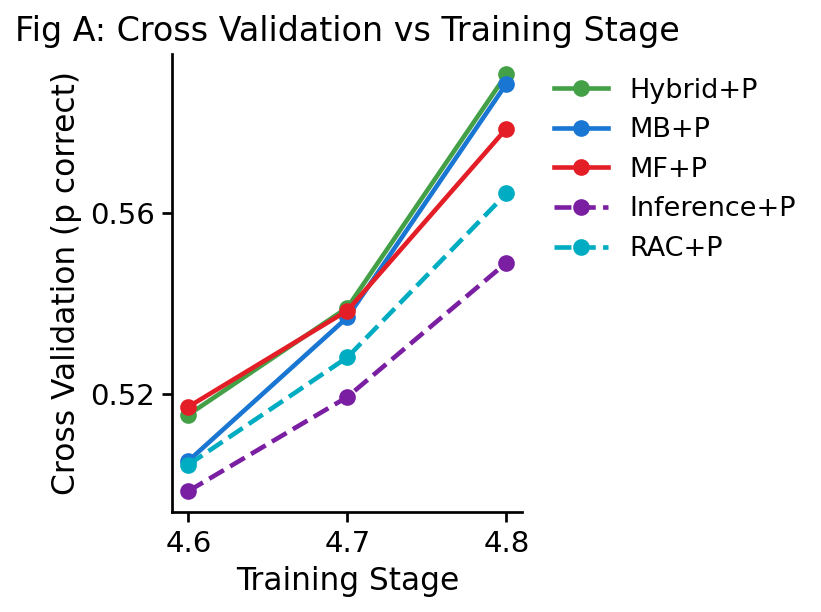

Saved FigA


In [4]:
# ============================================================
# Fig A — mean CV line plot
# ============================================================
FIGA_MODELS = [
    ('hyb_p',      '-'),
    ('mb_p',       '-'),
    ('mf_p',       '-'),
    ('ls_asym_p',  '--'),
    ('rac_p',      '--'),
]

fig, ax = plt.subplots(figsize=(5.5, 4.3))

for model_key, ls in FIGA_MODELS:
    means = [dfs[(model_key, s)]['Cross validation'].mean()
             if (model_key, s) in dfs else np.nan for s in STAGES]
    ax.plot(STAGE_X, means,
            linestyle=ls, marker='o', markersize=7, linewidth=2.2,
            color=clr(model_key), label=lbl(model_key))

ax.set_xticks(STAGE_X)
ax.set_xticklabels(STAGE_LABELS)
ax.set_xlabel('Training Stage')
ax.set_ylabel('Cross Validation (p correct)')
ax.set_title('Fig A: Cross Validation vs Training Stage')
tidy_yticks(ax, n=3)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'FigA_CV_vs_stage.png'), bbox_inches='tight')
plt.show()
print('Saved FigA')

## Fig B — Cross Validation Subject Variability
Grouped boxplot: 3 stage groups × 6 models.
T-tests (paired) comparing each model to Hybrid+P are reported below the figure.

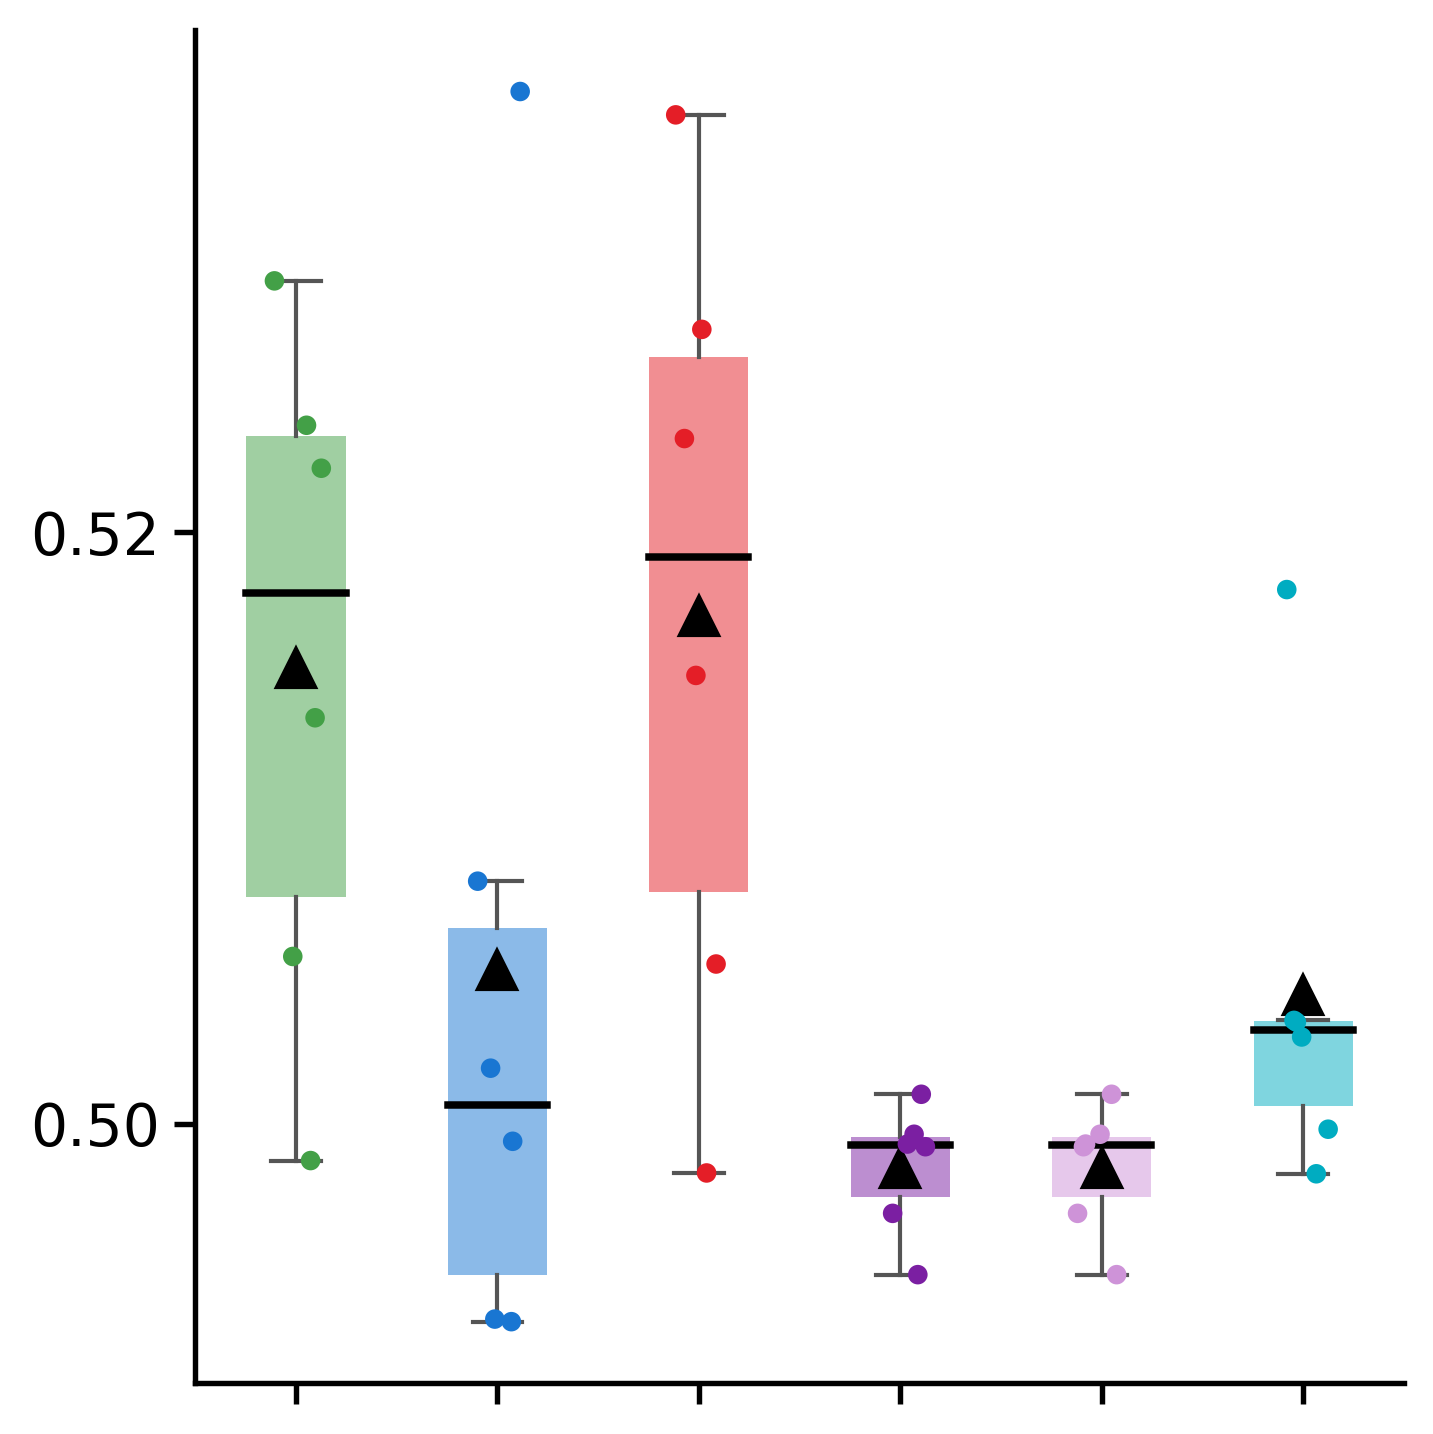

Saved FigB (stage 4.6)_nolabel


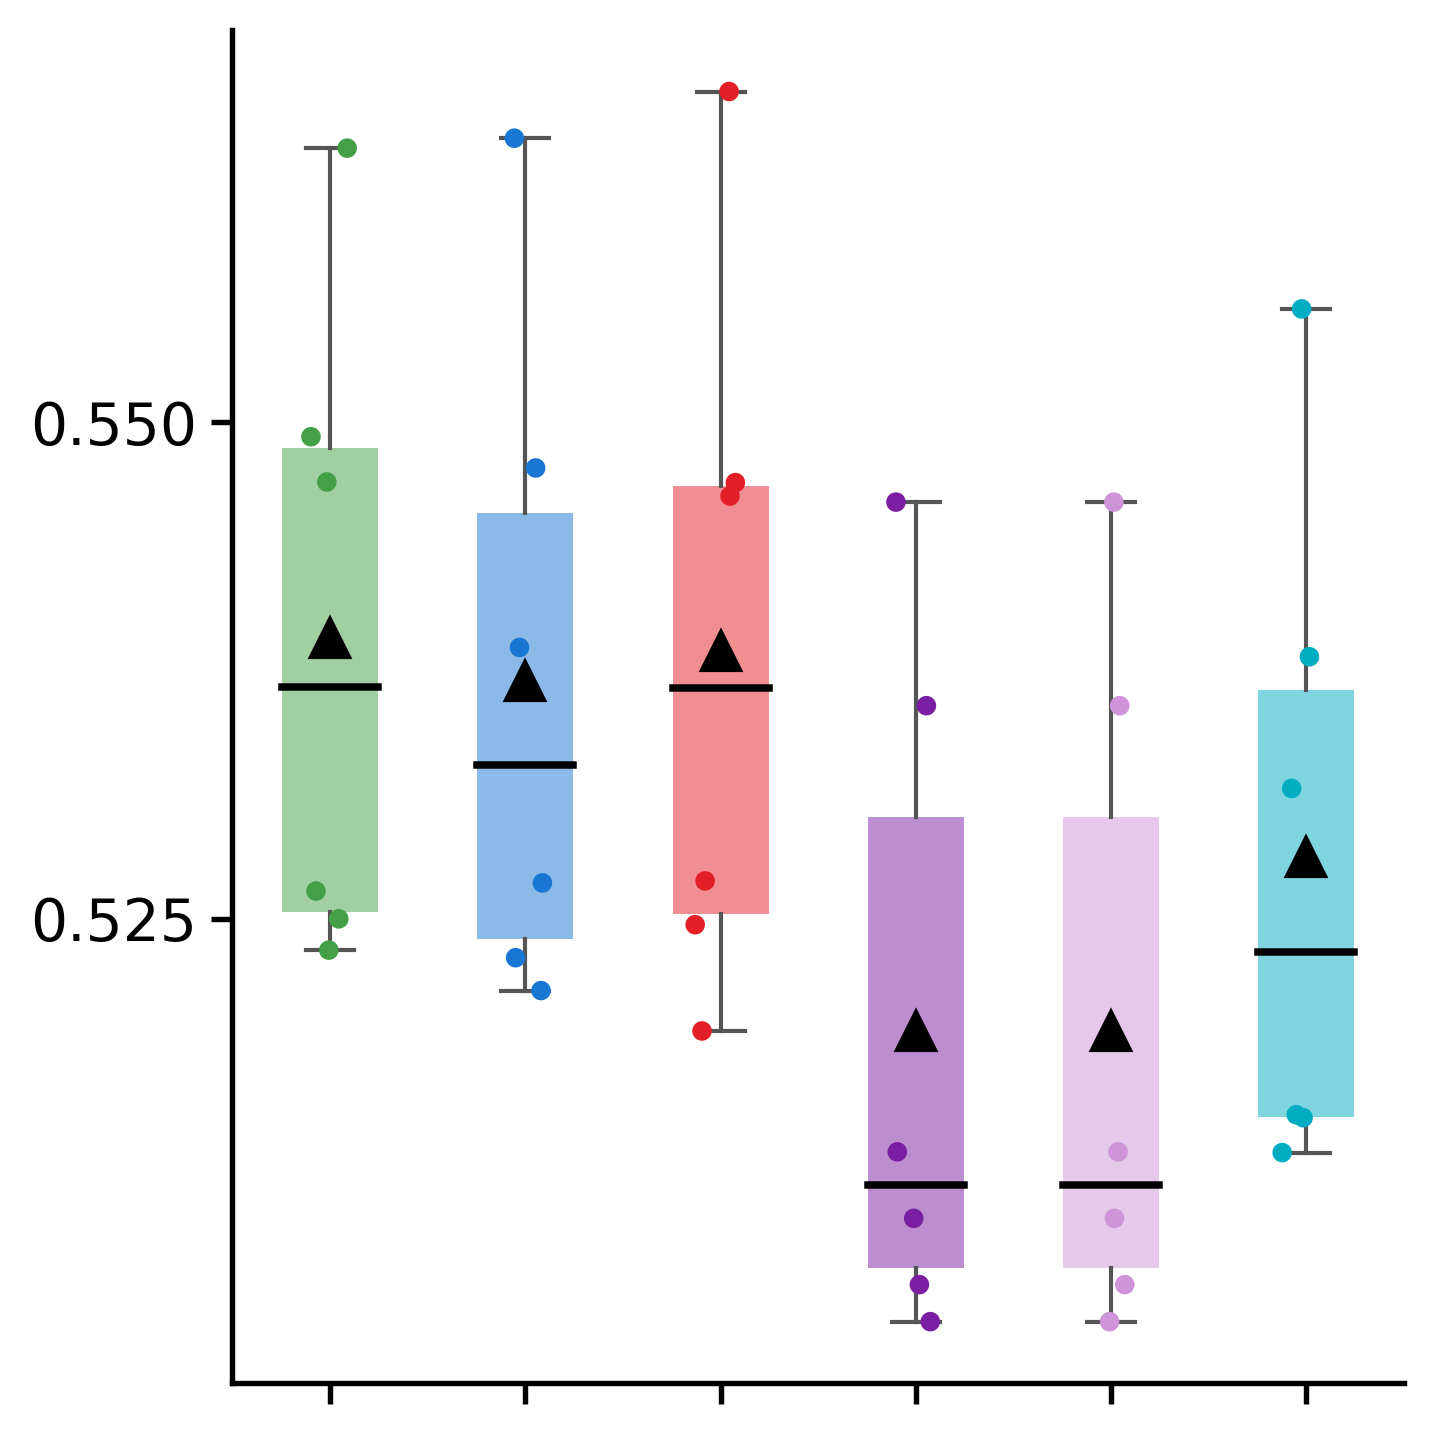

Saved FigB (stage 4.7)_nolabel


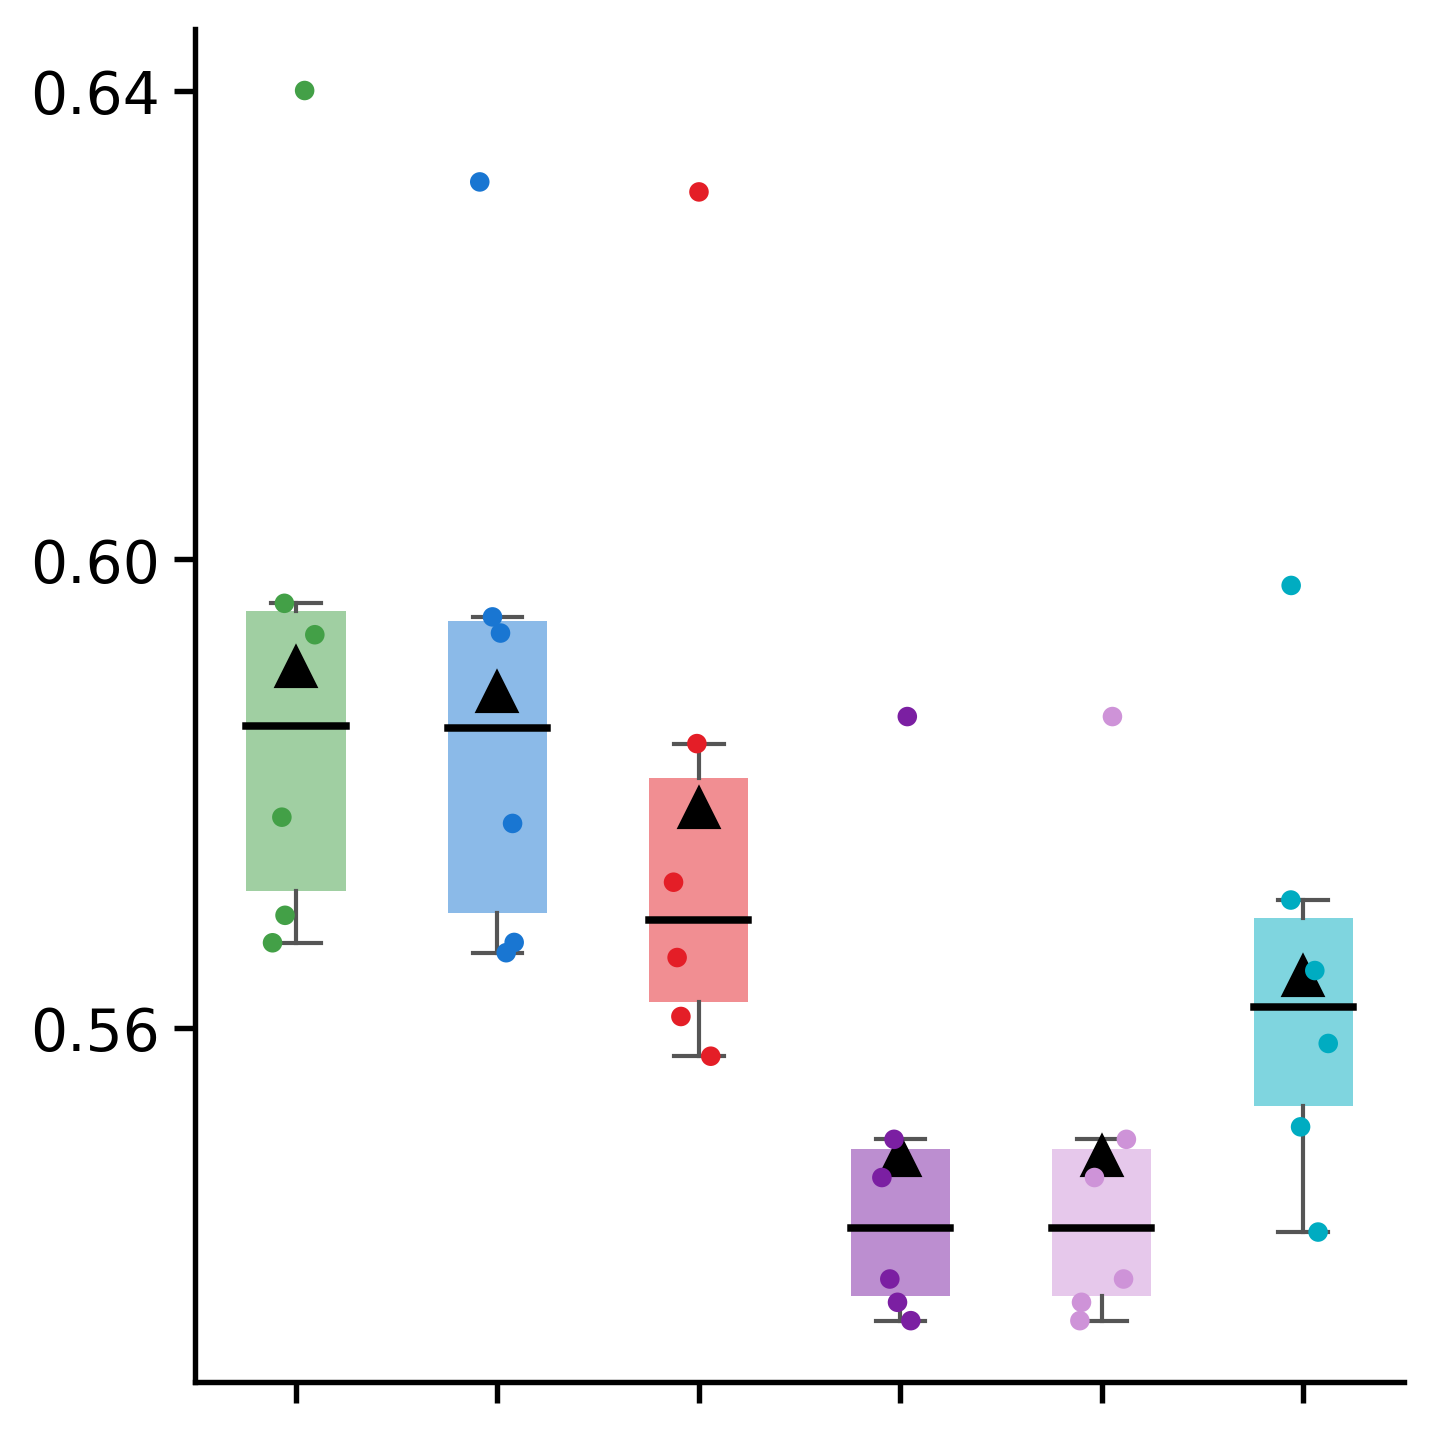

Saved FigB (stage 4.8)_nolabel

=== Fig B: Paired t-test (each model vs Hybrid+P) ===
Model                              Stage 4.6             Stage 4.7             Stage 4.8
----------------------------------------------------------------------------------------
MB+P                    t=+1.58 p=0.175 ns       t=+1.56 p=0.178 ns       t=+1.75 p=0.140 ns     
MF+P                    t=-0.85 p=0.433 ns       t=+0.66 p=0.540 ns       t=+6.24 p=0.002 **     
Inference+P             t=+3.93 p=0.011 *        t=+6.84 p=0.001 **       t=+11.25 p=0.000 ***    
LS+P                    t=+3.93 p=0.011 *        t=+6.84 p=0.001 **       t=+11.25 p=0.000 ***    
RAC+P                   t=+2.76 p=0.040 *        t=+9.41 p=0.000 ***      t=+7.12 p=0.001 ***    


In [27]:
# ============================================================
# Fig B — per-stage boxplot (one figure per stage) for 6 selected models
# Fixed model order (no sorting)
# ============================================================
FIGB_MODELS = [
    'hyb_p', 'mb_p', 'mf_p', 'ls_asym_p', 'ls_p', 'rac_p',
]
FIGB_MODELS = [m for m in FIGB_MODELS
               if any((m, s) in dfs for s in STAGES)]

# ── Paper toggle: set False to hide x-tick labels for clean paper figure ──
SHOW_XTICK_LABELS = False

rng = np.random.default_rng(42)
box_width = 0.6

MEAN_PROPS = dict(marker='^', markerfacecolor='black',
                  markeredgecolor='black', markersize=9)

for stage, stage_label in zip(STAGES, STAGE_LABELS):
    fig, ax = plt.subplots(figsize=(5,5), dpi=300)

    for mi, model_key in enumerate(FIGB_MODELS):
        if (model_key, stage) not in dfs:
            continue
        data = dfs[(model_key, stage)]['Cross validation'].values
        color = clr(model_key)

        ax.boxplot(
            data,
            positions=[mi],
            widths=box_width * 0.82,
            patch_artist=True,
            showfliers=False,
            showmeans=True,
            meanprops=MEAN_PROPS,
            medianprops=dict(color='black', linewidth=1.8),
            whiskerprops=dict(color='#555555', linewidth=1.0),
            capprops=dict(color='#555555', linewidth=1.0),
            boxprops=dict(facecolor=color, alpha=0.5,
                          edgecolor='none', linewidth=0),
        )

        jitter = rng.uniform(-box_width * 0.22, box_width * 0.22, size=len(data))
        ax.scatter(mi + jitter, data,
                   color=color, s=22, alpha=1.0, zorder=3,
                   edgecolors='none')

    ax.set_xticks(range(len(FIGB_MODELS)))
    if SHOW_XTICK_LABELS:
        ax.set_xticklabels([lbl(m) for m in FIGB_MODELS],
                           rotation=45, ha='right')
    else:
        ax.set_xticklabels([])
    # ax.set_ylabel('Cross Validation (p correct)')
    # ax.set_title(f'Fig B — Stage {stage_label}')
    tidy_yticks(ax, n=3)

    plt.tight_layout()
    suffix = '' if SHOW_XTICK_LABELS else '_nolabel'
    plt.savefig(os.path.join(FIGURES_DIR,
                f'FigB_CV_variability_stage{stage_label}{suffix}.png'),
                bbox_inches='tight')
    plt.show()
    print(f'Saved FigB (stage {stage_label}){suffix}')

# ── Paired t-tests vs Hybrid+P ──────────────────────────────────────────────
print('\n=== Fig B: Paired t-test (each model vs Hybrid+P) ===')
hdr = f"{'Model':<22}" + ''.join(f"{'Stage '+s:>22}" for s in STAGES)
print(hdr)
print('-' * (22 + 22 * len(STAGES)))
for model_key in [m for m in FIGB_MODELS if m != 'hyb_p']:
    row = f"{lbl(model_key):<22}"
    for stage in STAGES:
        if (model_key, stage) in dfs and ('hyb_p', stage) in dfs:
            a = dfs[('hyb_p',    stage)]['Cross validation'].values
            b = dfs[(model_key,  stage)]['Cross validation'].values
            t, p = stats.ttest_rel(a, b)
            sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
            row += f"  t={t:+.2f} p={p:.3f} {sig:3s}    "
        else:
            row += f"{'N/A':>22}"
    print(row)

## Fig C — Hybrid+P Parameters: Wmf and Wmb
Each subject shown as thin transparent line; mean ± SEM as thick line + shaded band.

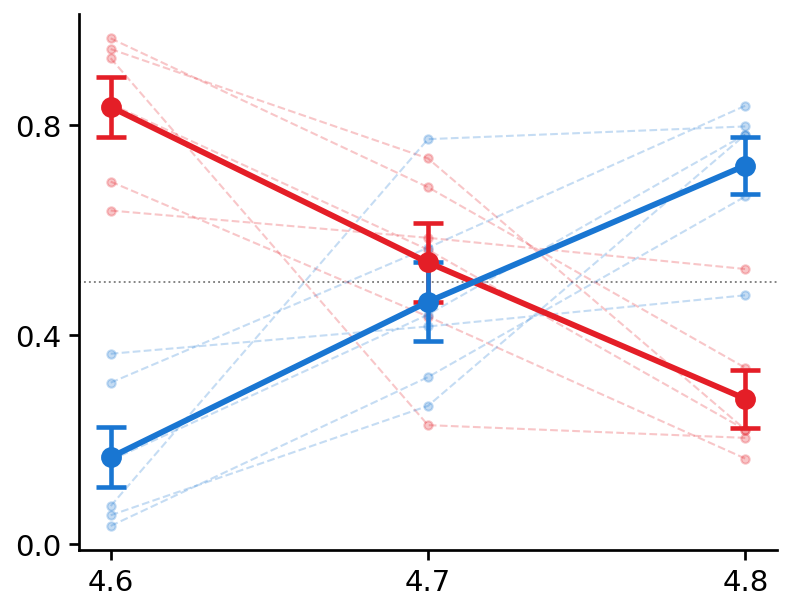

Saved FigC


In [28]:
# ============================================================
# Fig C — Hybrid+P Parameters: Wmf and Wmb (normalised so Wmf+Wmb=1)
# ============================================================
PARAM_COLORS = {'Wmf': '#E41E27', 'Wmb': '#1976D2'}

subj_norm = {p: {} for p in PARAM_COLORS}

for stage_idx, stage in enumerate(STAGES):
    if ('hyb_p', stage) not in dfs:
        continue
    d = dfs[('hyb_p', stage)].set_index('Subject')
    for subj in SUBJECTS:
        if subj not in d.index:
            continue
        if 'Wmf' not in d.columns or 'Wmb' not in d.columns:
            continue
        wmf = d.loc[subj, 'Wmf']
        wmb = d.loc[subj, 'Wmb']
        total = wmf + wmb
        if total == 0:
            continue
        subj_norm['Wmf'].setdefault(subj, {})[stage_idx] = wmf / total
        subj_norm['Wmb'].setdefault(subj, {})[stage_idx] = wmb / total

fig, ax = plt.subplots(figsize=(5.5, 4.3))

for param, color in PARAM_COLORS.items():
    for sv in subj_norm[param].values():
        xs = sorted(sv.keys())
        ys = [sv[x] for x in xs]
        ax.plot(xs, ys, color=color, alpha=0.25,
                linewidth=1.0, linestyle='--', marker='o',
                markersize=4, zorder=1)

    means, sems, valid_x = [], [], []
    for stage_idx in STAGE_X:
        vals = [sv[stage_idx] for sv in subj_norm[param].values()
                if stage_idx in sv]
        if vals:
            v = np.array(vals)
            means.append(v.mean())
            sems.append(v.std(ddof=1) / np.sqrt(len(v)))
            valid_x.append(stage_idx)

    ax.errorbar(valid_x, means, yerr=sems,
                color=color, linewidth=2.8, marker='o', markersize=9,
                capsize=7, capthick=2.2, elinewidth=2.2,
                label=param, zorder=2)

ax.axhline(0.5, color='grey', linewidth=0.9, linestyle=':', zorder=0)
ax.set_xticks(STAGE_X)
ax.set_xticklabels(STAGE_LABELS)
# ax.set_xlabel('Training Stage')
# ax.set_ylabel('Normalised weight')
# ax.set_title('Fig C: Hybrid+P — Wmf and Wmb')
tidy_yticks(ax, n=3)
# ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'FigC_hyb_p_params.png'), bbox_inches='tight')
plt.show()
print('Saved FigC')

## Fig C2 — Hybrid+Inf Parameters: Wmf and Winf (normalised)
Same style as Fig C but for the `hyb_inf` model.
Normalised so that Wmf + Winf = 1.

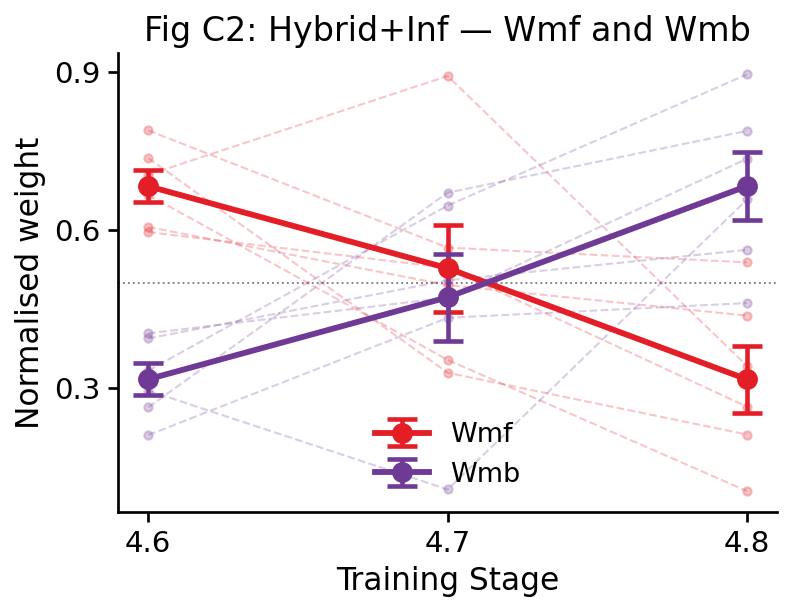

Saved FigC2


In [7]:
# ============================================================
# Fig C2 — Hybrid+Inf Parameters: Wmf and Wmb (normalised so Wmf+Wmb=1)
# ============================================================
PARAM_COLORS_INF = {'Wmf': '#E41E27', 'Wmb': '#6F3996'}

subj_norm_inf = {p: {} for p in PARAM_COLORS_INF}

for stage_idx, stage in enumerate(STAGES):
    if ('hyb_inf', stage) not in dfs:
        continue
    d = dfs[('hyb_inf', stage)].set_index('Subject')
    for subj in SUBJECTS:
        if subj not in d.index:
            continue
        if 'Wmf' not in d.columns or 'Wmb' not in d.columns:
            continue
        wmf = d.loc[subj, 'Wmf']
        wmb = d.loc[subj, 'Wmb']
        total = wmf + wmb
        if total == 0:
            continue
        subj_norm_inf['Wmf'].setdefault(subj, {})[stage_idx] = wmf / total
        subj_norm_inf['Wmb'].setdefault(subj, {})[stage_idx] = wmb / total

fig, ax = plt.subplots(figsize=(5.5, 4.3))

for param, color in PARAM_COLORS_INF.items():
    for sv in subj_norm_inf[param].values():
        xs = sorted(sv.keys())
        ys = [sv[x] for x in xs]
        ax.plot(xs, ys, color=color, alpha=0.25,
                linewidth=1.0, linestyle='--', marker='o',
                markersize=4, zorder=1)

    means, sems, valid_x = [], [], []
    for stage_idx in STAGE_X:
        vals = [sv[stage_idx] for sv in subj_norm_inf[param].values()
                if stage_idx in sv]
        if vals:
            v = np.array(vals)
            means.append(v.mean())
            sems.append(v.std(ddof=1) / np.sqrt(len(v)))
            valid_x.append(stage_idx)

    ax.errorbar(valid_x, means, yerr=sems,
                color=color, linewidth=2.8, marker='o', markersize=9,
                capsize=7, capthick=2.2, elinewidth=2.2,
                label=param, zorder=2)

ax.axhline(0.5, color='grey', linewidth=0.9, linestyle=':', zorder=0)
ax.set_xticks(STAGE_X)
ax.set_xticklabels(STAGE_LABELS)
ax.set_xlabel('Training Stage')
ax.set_ylabel('Normalised weight')
ax.set_title('Fig C2: Hybrid+Inf — Wmf and Wmb')
tidy_yticks(ax, n=3)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'FigC2_hyb_inf_params.png'), bbox_inches='tight')
plt.show()
print('Saved FigC2')

## Fig D — P vs P-multi Comparison
Left three panels: per-model-family comparison of +P (solid) vs +Pmulti (dashed).
Right panel: summary with all 6 lines together.

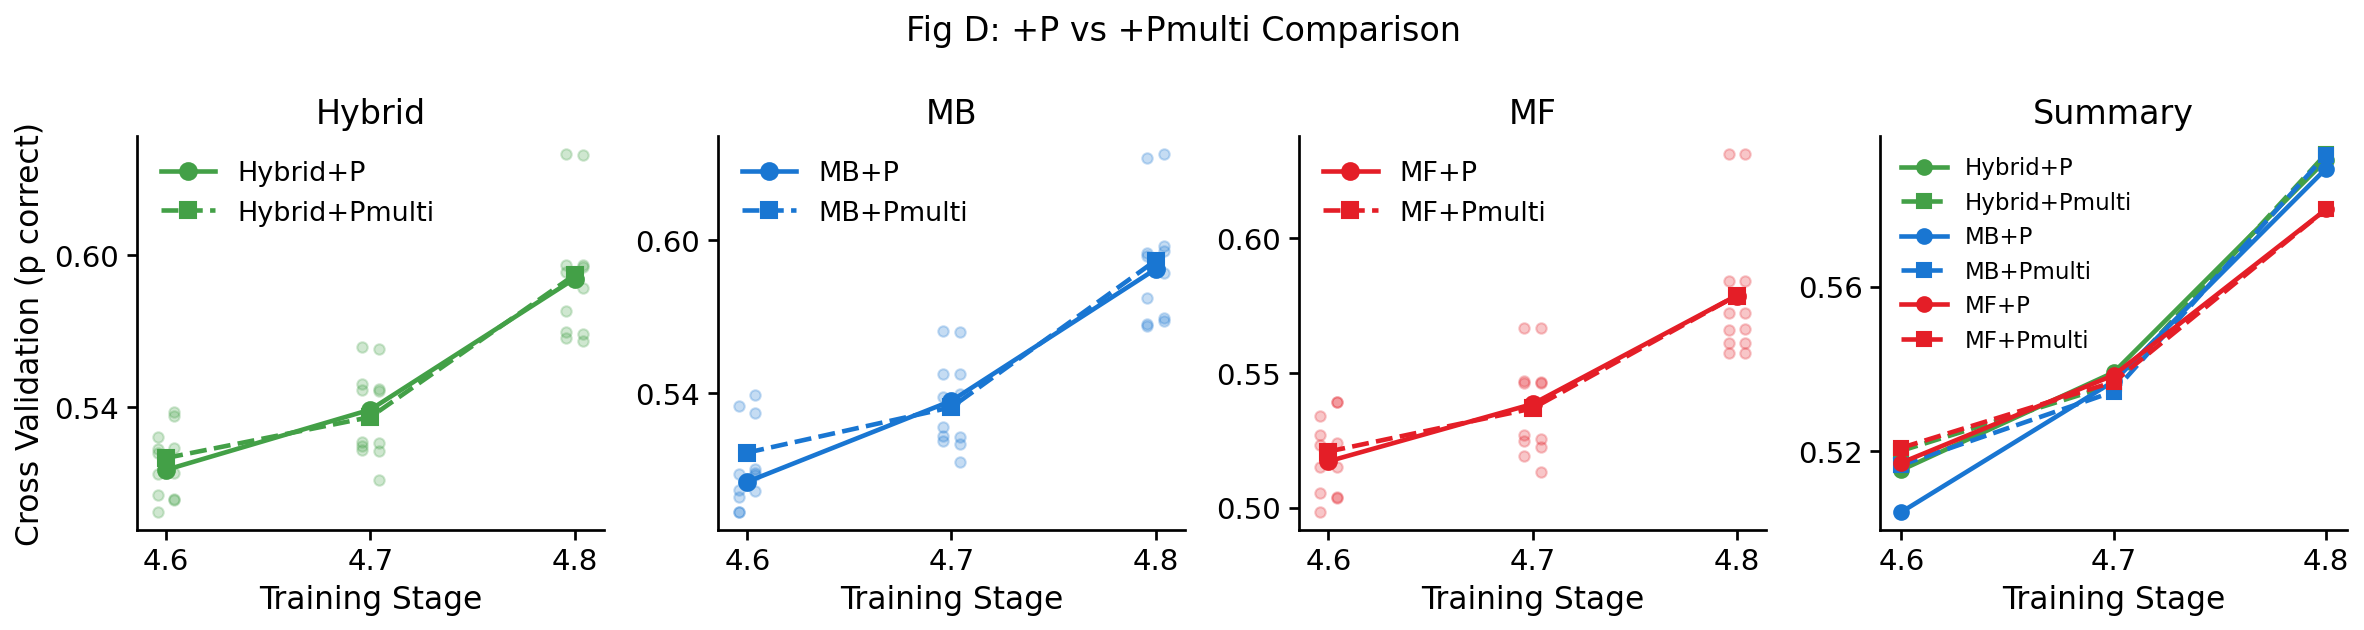

Saved FigD


In [8]:
# ============================================================
# Fig D — P vs Pmulti (line plots + summary)
# ============================================================
FIGD_PAIRS = [
    ('hyb_p', 'hyb_pmulti', 'Hybrid'),
    ('mb_p',  'mb_pmulti',  'MB'),
    ('mf_p',  'mf_pmulti',  'MF'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.3), sharey=False)

# ── Individual pair panels ────────────────────────────────────────────────
for i, (pk, pmk, name) in enumerate(FIGD_PAIRS):
    ax = axes[i]
    color = clr(pk)

    p_means  = [dfs[(pk,  s)]['Cross validation'].mean()
                if (pk,  s) in dfs else np.nan for s in STAGES]
    pm_means = [dfs[(pmk, s)]['Cross validation'].mean()
                if (pmk, s) in dfs else np.nan for s in STAGES]

    for stage_idx, stage in enumerate(STAGES):
        for key, offset, marker in [(pk, -0.04, 'o'), (pmk, 0.04, 's')]:
            if (key, stage) in dfs:
                vals = dfs[(key, stage)]['Cross validation'].values
                xs = [stage_idx + offset] * len(vals)
                ax.scatter(xs, vals, color=color, alpha=0.25,
                           s=25, zorder=1)

    ax.plot(STAGE_X, p_means,  color=color, linestyle='-',
            marker='o', linewidth=2.2, markersize=8, label=f'{name}+P',    zorder=2)
    ax.plot(STAGE_X, pm_means, color=color, linestyle='--',
            marker='s', linewidth=2.2, markersize=8, label=f'{name}+Pmulti', zorder=2)

    ax.set_xticks(STAGE_X)
    ax.set_xticklabels(STAGES)
    ax.set_xlabel('Training Stage')
    if i == 0:
        ax.set_ylabel('Cross Validation (p correct)')
    ax.set_title(name)
    tidy_yticks(ax, n=3)
    ax.legend(frameon=False)

# ── Summary panel (all 6 lines) ───────────────────────────────────────────
ax = axes[3]
for pk, pmk, name in FIGD_PAIRS:
    color = clr(pk)
    p_means  = [dfs[(pk,  s)]['Cross validation'].mean()
                if (pk,  s) in dfs else np.nan for s in STAGES]
    pm_means = [dfs[(pmk, s)]['Cross validation'].mean()
                if (pmk, s) in dfs else np.nan for s in STAGES]
    ax.plot(STAGE_X, p_means,  color=color, linestyle='-',
            marker='o', linewidth=2.2, markersize=7, label=f'{name}+P')
    ax.plot(STAGE_X, pm_means, color=color, linestyle='--',
            marker='s', linewidth=2.2, markersize=7, label=f'{name}+Pmulti')

ax.set_xticks(STAGE_X)
ax.set_xticklabels(STAGES)
ax.set_xlabel('Training Stage')
ax.set_title('Summary')
tidy_yticks(ax, n=3)
ax.legend(frameon=False, fontsize=11)

fig.suptitle('Fig D: +P vs +Pmulti Comparison', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'FigD_P_vs_Pmulti.png'), bbox_inches='tight')
plt.show()
print('Saved FigD')

## Fig E — All Models Cross Validation (extension of Fig B)
All available models, grouped by training stage.

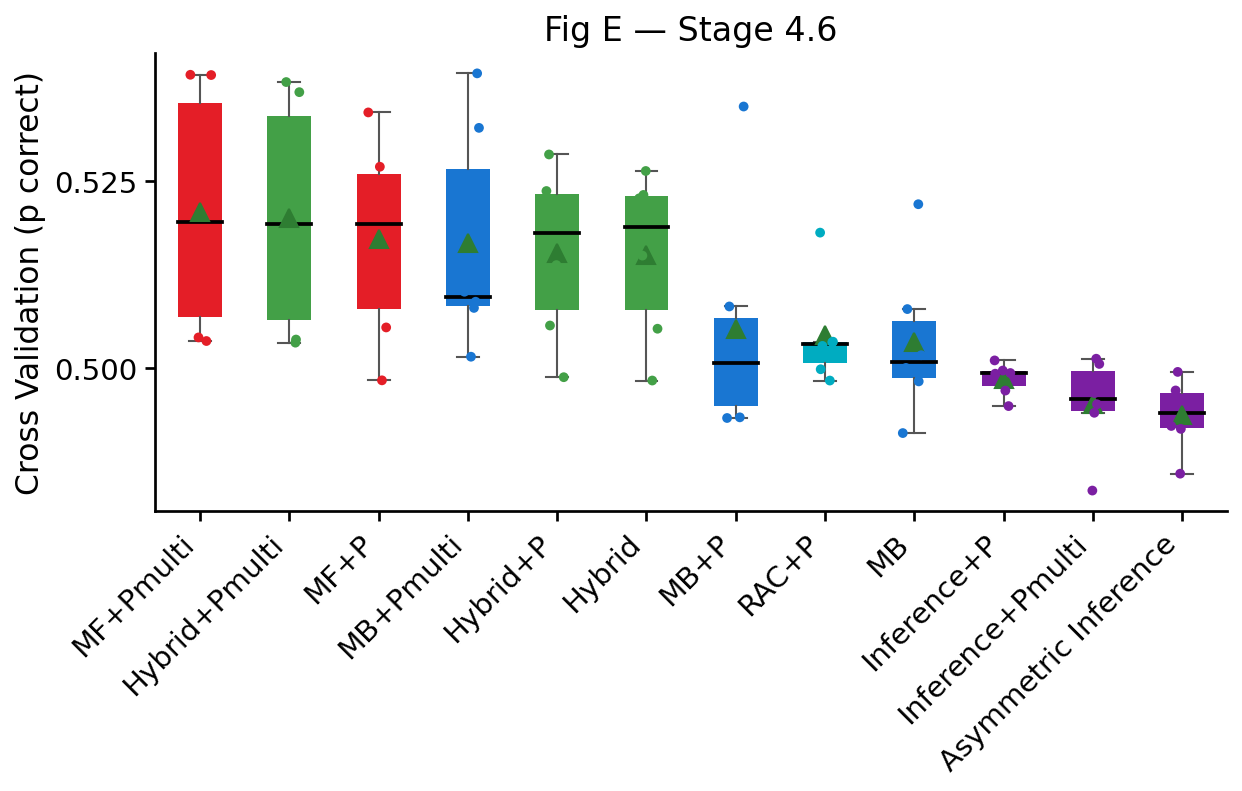

Saved FigE (stage 4.6)


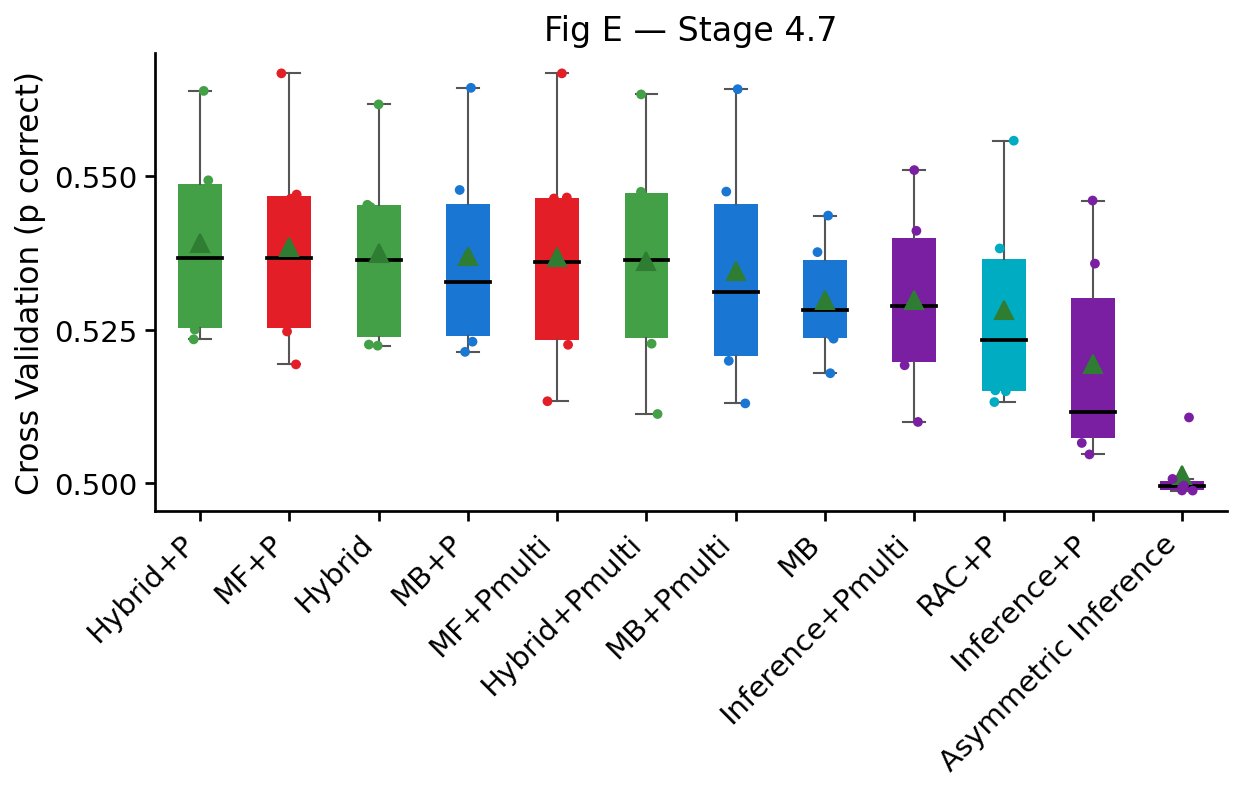

Saved FigE (stage 4.7)


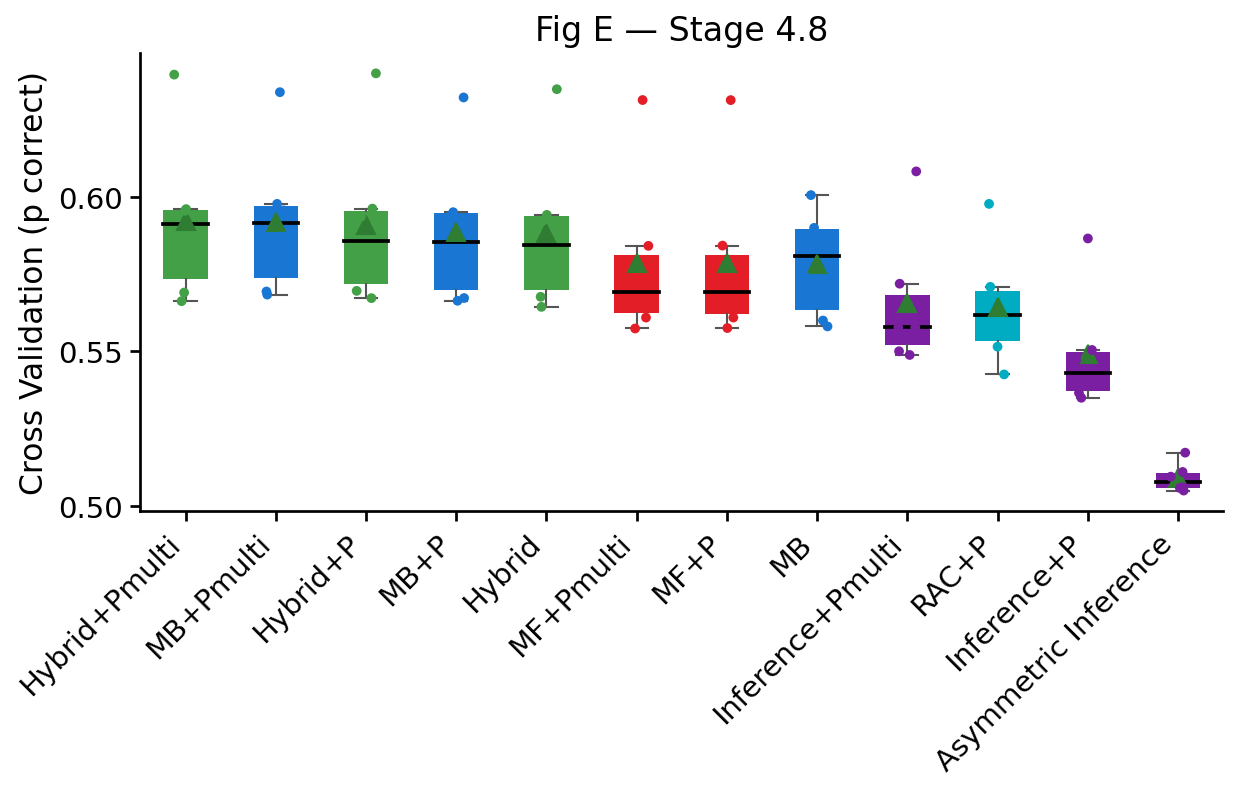

Saved FigE (stage 4.8)


In [ ]:
# ============================================================
# Fig E — all models boxplot (one figure per stage, sorted by mean CV desc)
# ============================================================
FIGE_MODELS = [
    'hyb', 'hyb_p', 'hyb_pmulti',
    'mb',  'mb_p',  'mb_pmulti',
    'mf_p', 'mf_pmulti',
    'ls_asym', 'ls_asym_p', 'ls_asym_pmulti',
    'rac_p',
]
FIGE_MODELS = [m for m in FIGE_MODELS
               if any((m, s) in dfs for s in STAGES)]

rng = np.random.default_rng(42)
box_width = 0.6

MEAN_PROPS = dict(marker='^', markerfacecolor='#2E7D32',
                  markeredgecolor='#2E7D32', markersize=9)

for stage, stage_label in zip(STAGES, STAGE_LABELS):
    def mean_cv(m):
        if (m, stage) in dfs:
            return dfs[(m, stage)]['Cross validation'].mean()
        return -np.inf

    sorted_models = sorted(FIGE_MODELS, key=mean_cv, reverse=True)

    fig, ax = plt.subplots(figsize=(8.5, 5.5))

    for mi, model_key in enumerate(sorted_models):
        if (model_key, stage) not in dfs:
            continue
        data = dfs[(model_key, stage)]['Cross validation'].values
        color = clr(model_key)

        ax.boxplot(
            data,
            positions=[mi],
            widths=box_width * 0.82,
            patch_artist=True,
            showfliers=False,
            showmeans=True,
            meanprops=MEAN_PROPS,
            medianprops=dict(color='black', linewidth=1.8),
            whiskerprops=dict(color='#555555', linewidth=1.0),
            capprops=dict(color='#555555', linewidth=1.0),
            boxprops=dict(facecolor=color, alpha=1.0,
                          edgecolor='none', linewidth=0),
        )

        jitter = rng.uniform(-box_width * 0.22, box_width * 0.22, size=len(data))
        ax.scatter(mi + jitter, data,
                   color=color, s=22, alpha=1.0, zorder=3,
                   edgecolors='none')

    ax.set_xticks(range(len(sorted_models)))
    ax.set_xticklabels([lbl(m) for m in sorted_models],
                       rotation=45, ha='right')
    ax.set_ylabel('Cross Validation')
    ax.set_title(f'Fig E — Stage {stage_label}')
    tidy_yticks(ax, n=3)

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f'FigE_all_models_stage{stage_label}.png'),
                bbox_inches='tight')
    plt.show()
    print(f'Saved FigE (stage {stage_label})')